<a href="https://colab.research.google.com/github/AhmadObaidat/School/blob/main/accuracy_score%2C_classification_report%2C_confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = [1, 0, 1, 1, 0, 0]
y_pred = [1, 0, 0, 1, 0, 1]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))


Accuracy: 0.6666666666666666
Confusion Matrix:
 [[2 1]
 [1 2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       423
           1       0.50      0.25      0.33        77

    accuracy                           0.85       500
   macro avg       0.69      0.60      0.62       500
weighted avg       0.82      0.85      0.82       500



<Figure size 640x480 with 0 Axes>

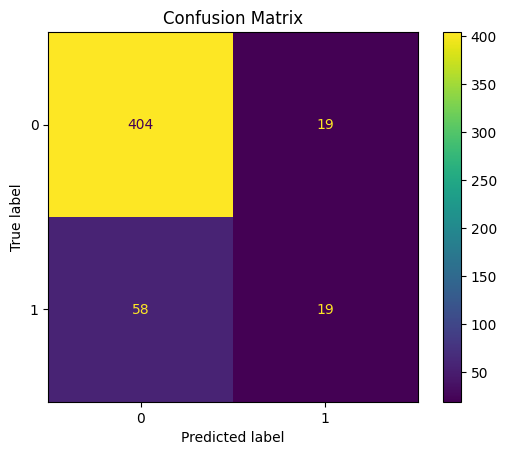

<Figure size 640x480 with 0 Axes>

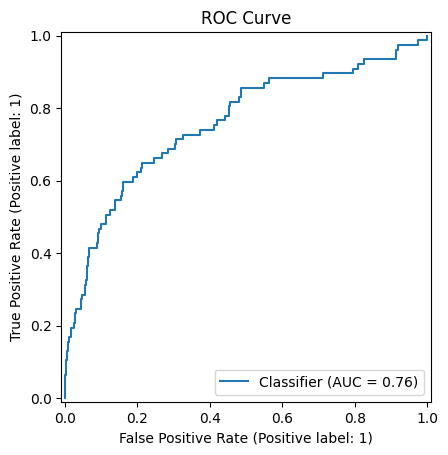

<Figure size 640x480 with 0 Axes>

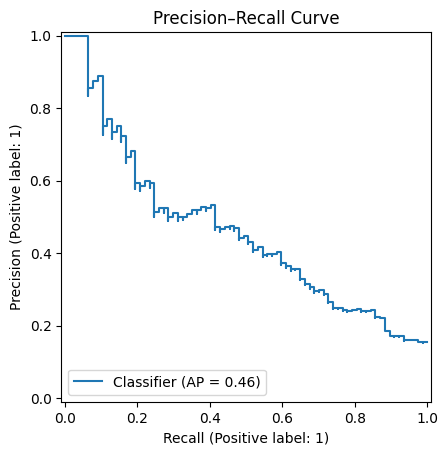

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

# 1) Create a sample binary classification dataset (slightly imbalanced)
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=8,
    n_redundant=2,
    weights=[0.85, 0.15],   # imbalance
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2) Train a simple model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions + probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # needed for ROC/PR curves

print("Classification Report:\n", classification_report(y_test, y_pred))

# 3) Visualization A: Confusion Matrix
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, values_format="d"
)
plt.title("Confusion Matrix")
plt.show()

# 4) Visualization B: ROC Curve
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.show()

# 5) Visualization C: Precision–Recall Curve
plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision–Recall Curve")
plt.show()



=== Accuracy ===
Accuracy: 0.8460

=== Precision / Recall / F1 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       423
           1       0.50      0.25      0.33        77

    accuracy                           0.85       500
   macro avg       0.69      0.60      0.62       500
weighted avg       0.82      0.85      0.82       500



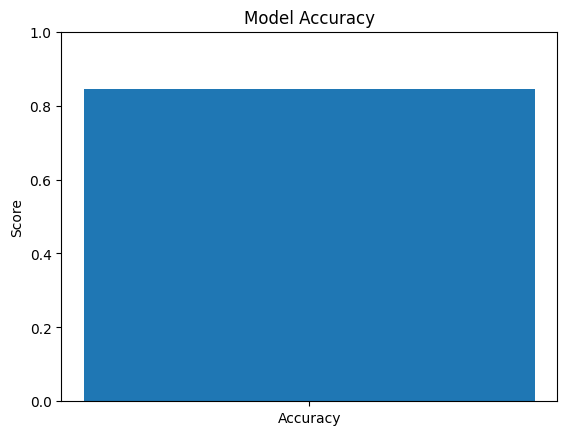

<Figure size 640x480 with 0 Axes>

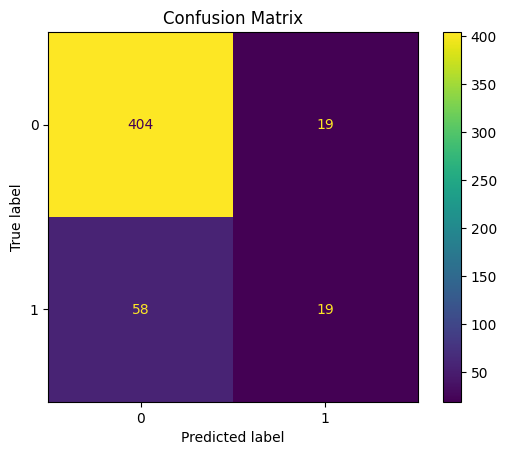

<Figure size 640x480 with 0 Axes>

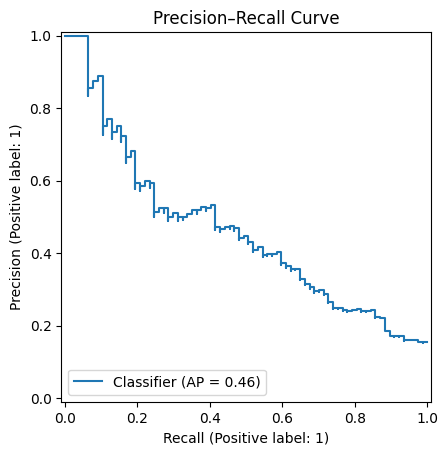


=== Cross-Validation (Accuracy) ===
Fold scores: [0.865  0.875  0.865  0.865  0.8675]
Mean CV Accuracy: 0.8675
Std CV Accuracy:  0.0039


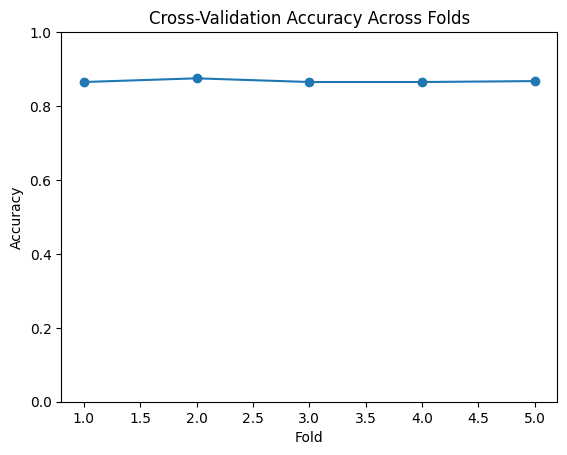

In [ ]:
# All-in-one evaluation + visuals for:
# Accuracy, Confusion Matrix, Precision-Recall-F1, and Cross-Validation
# (scikit-learn + matplotlib only)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
)

# ----------------------------
# 1) Create data (slightly imbalanced, realistic)
# ----------------------------
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=8,
    n_redundant=2,
    weights=[0.85, 0.15],   # class imbalance
    flip_y=0.01,
    class_sep=1.0,
    random_state=42,
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ----------------------------
# 2) Train a supervised model
# ----------------------------
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# Predictions + probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ----------------------------
# 3) Metrics (Accuracy + Precision/Recall/F1)
# ----------------------------
acc = accuracy_score(y_test, y_pred)
print("\n=== Accuracy ===")
print(f"Accuracy: {acc:.4f}")

print("\n=== Precision / Recall / F1 (Classification Report) ===")
print(classification_report(y_test, y_pred))

# ----------------------------
# 4) Visual A: Accuracy (bar)
# ----------------------------
plt.figure()
plt.bar(["Accuracy"], [acc])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# ----------------------------
# 5) Visual B: Confusion Matrix
# ----------------------------
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, values_format="d"
)
plt.title("Confusion Matrix")
plt.show()

# ----------------------------
# 6) Visual C: Precision–Recall Curve
# ----------------------------
plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision–Recall Curve")
plt.show()

# ----------------------------
# 7) Cross-Validation + Visual
# ----------------------------
# Use a fresh model object for CV (best practice)
cv_model = LogisticRegression(max_iter=3000)

cv_scores = cross_val_score(
    cv_model, X, y, cv=5, scoring="accuracy"
)

print("\n=== Cross-Validation (Accuracy) ===")
print("Fold scores:", np.round(cv_scores, 4))
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std CV Accuracy:  {cv_scores.std():.4f}")

plt.figure()
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o")
plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy Across Folds")
plt.show()
